In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.ticker import PercentFormatter
from pandas.api.types import is_numeric_dtype
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')

In [2]:
def ordered_set(lst):
    return list(dict.fromkeys(lst))

In [3]:
def simpleaxis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

In [4]:
def weighted_spearman(x, y, weights):
    # Check inputs
    x = np.array(x)
    y = np.array(y)
    weights = np.array(weights)
    
    if len(x) != len(y) or len(x) != len(weights):
        raise ValueError("x, y, and weights must have the same length")
    
    # Compute ranks
    x_rank = np.argsort(np.argsort(x))
    y_rank = np.argsort(np.argsort(y))
    
    # Weighted covariance
    mean_x = np.average(x_rank, weights=weights)
    mean_y = np.average(y_rank, weights=weights)
    
    cov_xy = np.sum(weights * (x_rank - mean_x) * (y_rank - mean_y)) / np.sum(weights)
    
    # Weighted variances
    var_x = np.sum(weights * (x_rank - mean_x) ** 2) / np.sum(weights)
    var_y = np.sum(weights * (y_rank - mean_y) ** 2) / np.sum(weights)
    
    # Weighted Spearman correlation
    corr = cov_xy / (np.sqrt(var_x) * np.sqrt(var_y))
    
    return corr

In [5]:
eicv = pd.read_csv('clean_data/eicv.csv')
eicv.head()

,ownhouse,wall_detail,roof_detail,floor_detail,water,toilet,toiletshared,lighting,cooking,television,...,categorical_vup,nchildren5,nchildren12,nchildren18,nelderly,ndisabled,nfemale,any_member_literate,land,any_member_education
0,1,"1. Wood, mud, and/or cement",1. Iron sheets,2. Cement,2. Public tap,2. Pit latrine with slabs,1,1. Electricity,3. Charcoal,0,...,0,0,0,0,0,0,0,1,1,2. Primary
1,1,"1. Wood, mud, and/or cement",1. Iron sheets,1. Earth,2. Public tap,2. Pit latrine with slabs,1,1. Electricity,3. Charcoal,0,...,0,1,2,2,0,0,2,1,1,2. Primary
2,1,"1. Wood, mud, and/or cement",1. Iron sheets,2. Cement,2. Public tap,2. Pit latrine with slabs,1,1. Electricity,3. Charcoal,1,...,0,0,1,1,0,0,2,1,1,2. Primary
3,1,"1. Wood, mud, and/or cement",1. Iron sheets,2. Cement,2. Public tap,2. Pit latrine with slabs,1,1. Electricity,3. Charcoal,1,...,0,1,1,1,0,0,3,1,1,5. University
4,1,4. Oven-fired bricks,1. Iron sheets,2. Cement,2. Public tap,2. Pit latrine with slabs,1,1. Electricity,3. Charcoal,1,...,0,0,0,0,0,0,0,1,0,5. University


In [7]:
outcomes = ['consumption', 'log_consumption', 'weight_new', 'ubudehe_cat', 'below_pl', 'hhid',
            'categorical_vup']
dummies = ['wall_detail', 'roof_detail', 'floor_detail', 'district', 'cooking', 'toilet', 'water', 
           'marital', 'education', 'any_member_education', 'lighting']
continuous = ['number_Cattle', 'number_Goats', 'number_Chickens', 'number_Pigs', 'number_Sheep',
             'number_Rabbits', 'ageyrs', 'hhsize', 'nchildren5', 'nchildren12', 'nchildren18', 'nelderly', 
              'nfemale', 'ndisabled']
#continuous = ['number_Cattle', 'number_Chickens', 'number_Goats', 'number_Pigs', 'number_Sheep',
#             'number_Rabbits', 'ageyrs', 'hhsize', 'nchildren5', 'nchildren12', 'nchildren18', 'nelderly', 
#              'nfemale', 'ndisabled']
#continuous = ['ageyrs', 'hhsize', 'nchildren5', 'nchildren12', 'nchildren18', 'nelderly', 
#              'nfemale', 'ndisabled', 'small_animals', 'dependency_ratio']

eicv = pd.read_csv('clean_data/eicv.csv')
#small_animals = ['number_Chickens', 'number_Goats', 'number_Pigs', 'number_Sheep', 'number_Rabbits']
#eicv['small_animals'] = 0
#for s in small_animals:
#    eicv['small_animals'] = eicv['small_animals'] + eicv[s]
#eicv = eicv.drop(small_animals, axis=1)
#eicv['dependency_ratio'] = eicv['nchildren12'] + eicv['nelderly']
#eicv['denom'] = (eicv['hhsize'] - eicv['dependency_ratio']).apply(lambda x: max(1, x))
#eicv['dependency_ratio'] = 100*(eicv['dependency_ratio']/eicv['denom'])
#eicv = eicv.drop('denom', axis=1)

#eicv = pd.read_csv('clean_data/eicv.csv')#.drop('lighting', axis=1)
for c in eicv.columns:
    if is_numeric_dtype(eicv[c]):
        eicv[c] = eicv[c].astype('int')
eicv = pd.get_dummies(eicv, columns=dummies, drop_first=True, prefix_sep='___')



sr = pd.read_csv('clean_data/sr.csv')#.drop('lighting', axis=1)
for c in sr.columns:
    if is_numeric_dtype(sr[c]):
        sr[c] = sr[c].astype('int')
sr = pd.get_dummies(sr, columns=dummies, drop_first=True, prefix_sep='___')

#for c in continuous:
#    eicv[c] = (eicv[c] - np.min(eicv[c])) / (np.max(eicv[c]) - np.min(eicv[c]))
#    sr[c] = (sr[c] - np.min(sr[c])) / (np.max(sr[c]) - np.min(sr[c]))

In [8]:
# Stepwise forward selection
def forward_stepwise_ols(train, test, random_seed, n_folds):
    xvars = [c for c in eicv.columns if c not in outcomes]
    x_train, x_test = train[xvars], test[xvars]
    outcome = 'log_consumption'
    y_train, y_test = train[outcome], test[outcome]
    weights_train, weights_test = train['weight_new'], test['weight_new']
    varlists, nonzero_varlists, models, r2s, spearmans, prec_16s, prec_40s = [], [], [], [], [], [], []
    recall_16s, recall_40s = [], []
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    train_ids, val_ids = train_test_split(range(len(y_train)), random_state=random_seed, test_size=0.25)
    remaining = list(x_train.columns)
    selected, current_vars = [], [] 
    
    while len(remaining) > 0:
        mse_current = 10000000000
        for var in remaining:
            candidates = selected + [var]
            mse_candidate = np.zeros(n_folds)
            for k, (train_ids, val_ids) in enumerate(kfold.split(range(len(x_train)))):
                model = LinearRegression()
                model.fit(x_train.iloc[train_ids][candidates], y_train.iloc[train_ids], 
                          sample_weight=weights_train.iloc[train_ids])
                yhat_val = model.predict(x_train.iloc[val_ids][candidates])
                mse_candidate[k] = mean_squared_error(y_train.iloc[val_ids], yhat_val)
            if np.mean(mse_candidate) < mse_current:
                current_vars = candidates
                mse_current = np.mean(mse_candidate)
        remaining = [c for c in remaining if c not in current_vars]
        selected = current_vars + [c for c in remaining if c.split('___')[0] in 
                                   set([c.split('___')[0] for c in current_vars])]
        nvars = len(set([c.split('___')[0] for c in selected]))
        remaining = [c for c in remaining if c not in selected]
        
        model = LassoCV()
        model.fit(x_train[selected], y_train, sample_weight=weights_train)
        yhat_test = model.predict(x_test[selected])
        varlists.append(selected)
        nonzero_vars = [c for i, c in enumerate(selected) if model.coef_[i] != 0]
        nonzero_varlists.append(nonzero_vars)
        models.append(model)
        r2 = r2_score(y_test, yhat_test, sample_weight=weights_test)
        spearman = weighted_spearman(y_test, yhat_test, weights_test)
        r2s.append(r2)
        spearmans.append(spearman)
        
        # Accuracy - 16% cut-off
        evalset = test.copy()
        evalset['prediction_lr'] = model.predict(x_test[selected])
        weight_targeted = 0.16*evalset['weight_new'].sum()
        evalset = evalset.sort_values('prediction_lr', ascending=True)
        evalset['cum_weight'] = evalset['weight_new'].cumsum()
        evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
        targeted = evalset[evalset['targeted'] == 1]
        pmt_accuracy_16 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
        prec_16s.append(pmt_accuracy_16)
        poor = evalset[evalset['below_pl'] == 1]
        pmt_recall_16 = poor[poor['targeted'] == 1]['weight_new'].sum()/poor['weight_new'].sum()
        recall_16s.append(pmt_recall_16)

        # Accuracy - 40% cut-off
        evalset = test.copy()
        evalset['prediction_lr'] = model.predict(x_test[selected])
        weight_targeted = 0.40*evalset['weight_new'].sum()
        evalset = evalset.sort_values('prediction_lr', ascending=True)
        evalset['cum_weight'] = evalset['weight_new'].cumsum()
        evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
        targeted = evalset[evalset['targeted'] == 1]
        pmt_accuracy_40 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
        prec_40s.append(pmt_accuracy_40)
        poor = evalset[evalset['below_pl'] == 1]
        pmt_recall_40 = poor[poor['targeted'] == 1]['weight_new'].sum()/poor['weight_new'].sum()
        recall_40s.append(pmt_recall_40)
        
        print(nvars, len(ordered_set([c.split('___')[0] for c in nonzero_vars])), np.round(spearman, 2), 
              np.round(pmt_accuracy_16, 2),  np.round(pmt_accuracy_40, 2))
    
    return varlists, nonzero_varlists, models, r2s, spearmans, prec_16s, prec_40s, recall_16s, recall_40s

In [9]:
train, test = train_test_split(eicv, test_size=0.25, random_state=9, shuffle=True, 
                               stratify=eicv['ubudehe_cat'])

varlists, nonzero_varlists, models, r2s, spearmans, prec_16s, prec_40s, recall_16s, recall_40s = \
    forward_stepwise_ols(train, test, 0, 3)

1 1 0.3 0.44 0.44
2 2 0.36 0.49 0.48
3 3 0.44 0.67 0.6
4 4 0.48 0.74 0.6
5 5 0.49 0.76 0.59
6 6 0.53 0.77 0.63
7 7 0.55 0.78 0.64
8 8 0.55 0.79 0.64
9 9 0.56 0.8 0.64
10 10 0.55 0.79 0.64
11 11 0.56 0.8 0.64
12 12 0.56 0.8 0.64
13 13 0.56 0.8 0.65
14 14 0.56 0.8 0.65
15 15 0.57 0.8 0.65
16 16 0.57 0.81 0.65
17 17 0.57 0.81 0.65
18 18 0.57 0.81 0.66
19 19 0.57 0.81 0.65
20 20 0.57 0.81 0.66
21 21 0.57 0.81 0.65
22 22 0.57 0.81 0.66
23 23 0.57 0.82 0.66
24 24 0.57 0.81 0.66
25 25 0.57 0.82 0.66
26 26 0.57 0.82 0.66
27 27 0.58 0.82 0.66
28 28 0.58 0.82 0.66
29 29 0.58 0.81 0.66
30 30 0.58 0.81 0.66
31 31 0.58 0.81 0.66
32 32 0.58 0.81 0.66
33 33 0.58 0.82 0.66
34 34 0.58 0.81 0.66
35 35 0.58 0.81 0.66
36 35 0.58 0.81 0.66
37 36 0.58 0.81 0.66
38 37 0.58 0.81 0.66
39 38 0.58 0.82 0.67
40 39 0.58 0.82 0.67
41 40 0.58 0.82 0.67


In [12]:
train, test = train_test_split(eicv, test_size=0.25, random_state=9, shuffle=True, 
                               stratify=eicv['ubudehe_cat'])

train_urban = train[train['urban___1'] == 1]
train_rural = train[train['urban___1'] == 0]
test_urban = test[test['urban___1'] == 1]
test_rural = test[test['urban___1'] == 0]

In [14]:
varlists_urban, nonzero_varlists_urban, models_urban, r2s, spearmans, prec_16s, prec_40s, recall_16s, recall_40s = \
    forward_stepwise_ols(train_urban, test_urban, 0, 3)

1 1 0.37 0.46 0.31
2 2 0.41 0.56 0.33
3 3 0.49 0.57 0.33
4 4 0.53 0.58 0.36
5 5 0.54 0.58 0.35
6 6 0.55 0.58 0.35
7 7 0.55 0.6 0.36
8 8 0.55 0.6 0.35
9 9 0.56 0.6 0.35
10 10 0.58 0.62 0.36
11 11 0.58 0.62 0.36
12 11 0.59 0.61 0.36
13 13 0.59 0.62 0.36
14 14 0.59 0.62 0.36
15 15 0.59 0.62 0.37
16 16 0.59 0.62 0.37
17 17 0.59 0.61 0.37
18 18 0.59 0.62 0.37
19 19 0.59 0.62 0.38
20 20 0.59 0.62 0.38
21 21 0.59 0.62 0.38
22 20 0.59 0.62 0.39
23 20 0.59 0.62 0.39
24 23 0.59 0.61 0.39
25 21 0.59 0.61 0.38
26 22 0.59 0.62 0.39
27 23 0.59 0.6 0.38
28 24 0.59 0.61 0.39
29 22 0.59 0.6 0.39
30 25 0.59 0.6 0.38
31 27 0.59 0.6 0.38
32 27 0.59 0.6 0.38
33 26 0.59 0.61 0.38
34 26 0.59 0.61 0.38
35 26 0.59 0.6 0.39
36 27 0.59 0.61 0.39
37 27 0.59 0.61 0.39
38 28 0.59 0.6 0.39
39 28 0.59 0.6 0.39
40 29 0.59 0.6 0.39
41 29 0.59 0.6 0.39


In [15]:
varlists_rural, nonzero_varlists_rural, models_rural, r2s, spearmans, prec_16s, prec_40s, recall_16s, recall_40s = \
    forward_stepwise_ols(train_rural, test_rural, 0, 3)

1 1 0.18 0.47 0.46
2 2 0.34 0.67 0.6
3 3 0.38 0.75 0.63
4 4 0.43 0.8 0.64
5 5 0.45 0.8 0.67
6 6 0.46 0.8 0.67
7 7 0.46 0.8 0.67
8 8 0.47 0.79 0.66
9 9 0.47 0.79 0.67
10 10 0.48 0.81 0.68
11 11 0.49 0.82 0.68
12 12 0.49 0.82 0.67
13 13 0.49 0.81 0.68
14 14 0.49 0.82 0.68
15 15 0.49 0.82 0.68
16 16 0.49 0.82 0.68
17 17 0.49 0.81 0.69
18 18 0.49 0.82 0.69
19 19 0.5 0.82 0.69
20 20 0.5 0.82 0.69
21 21 0.5 0.83 0.69
22 22 0.5 0.83 0.69
23 23 0.5 0.83 0.69
24 24 0.5 0.83 0.69
25 25 0.5 0.83 0.69
26 26 0.51 0.82 0.69
27 27 0.51 0.83 0.69
28 28 0.51 0.83 0.69
29 29 0.51 0.82 0.69
30 30 0.51 0.83 0.69
31 30 0.51 0.83 0.69
32 31 0.51 0.84 0.7
33 31 0.51 0.84 0.7
34 32 0.51 0.83 0.69
35 33 0.51 0.84 0.69
36 34 0.51 0.84 0.69
37 34 0.51 0.84 0.69
38 34 0.51 0.84 0.69
39 35 0.51 0.84 0.69
40 36 0.51 0.83 0.69
41 37 0.51 0.83 0.69


In [26]:
nvars = 14
share_targeted = .40

evalset1 = test_urban.copy()
evalset1['prediction_lr'] = models_urban[nvars].predict(evalset1[varlists_urban[14]])

evalset2 = test_rural.copy()
evalset2['prediction_lr'] = models_rural[nvars].predict(evalset2[varlists_rural[14]])

evalset = pd.concat([evalset1, evalset2])
weight_targeted = share_targeted*evalset['weight_new'].sum()
evalset = evalset.sort_values('prediction_lr', ascending=True)
evalset['cum_weight'] = evalset['weight_new'].cumsum()
evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
targeted = evalset[evalset['targeted'] == 1]
pmt_accuracy_40 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
print(pmt_accuracy_40)
poor = evalset[evalset['below_pl'] == 1]
pmt_recall_40 = poor[poor['targeted'] == 1]['weight_new'].sum()/poor['weight_new'].sum()
print(pmt_recall_40)
        

0.6520152477360444
0.7010132973959622


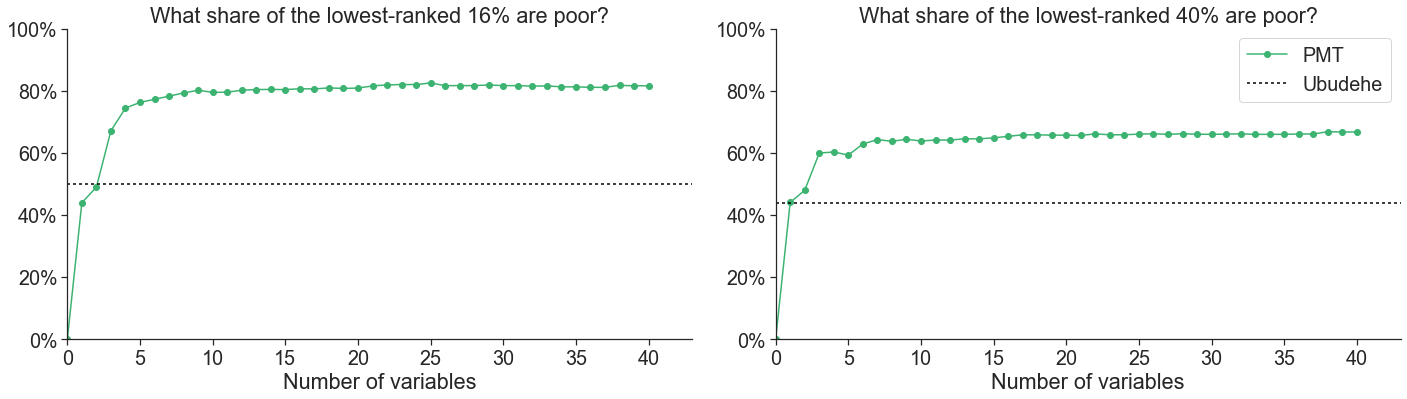

In [49]:
sns.set(font_scale=1.8, style='white')
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
nvars = [len(set([c.split('___')[0] for c in selected])) for selected in varlists]

ax[0].plot([0] + nvars, [0] + [x*100 for x in prec_16s], marker='o', color='mediumseagreen', label='PMT')
ax[1].plot([0] + nvars, [0] + [x*100 for x in prec_40s], marker='o', color='mediumseagreen', label='PMT')
ax[0].axhline(50, label='Ubudehe', color='black', dashes=[2, 2])
ax[1].axhline(44, label='Ubudehe', color='black', dashes=[2, 2])
simpleaxis(ax[0])
simpleaxis(ax[1])
ax[0].set_xlabel('Number of variables')
ax[1].set_xlabel('Number of variables')
ax[0].set_title('What share of the lowest-ranked 16% are poor?')
ax[1].set_title('What share of the lowest-ranked 40% are poor?')
ax[0].set_ylim(0, 100)
ax[1].set_ylim(0, 100)
ax[0].set_xlim(0, 43)
ax[1].set_xlim(0, 43)
ax[-1].legend(loc='best')
ax[0].yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.tight_layout()
#plt.savefig('stepwise.png', dpi=500)
plt.show()

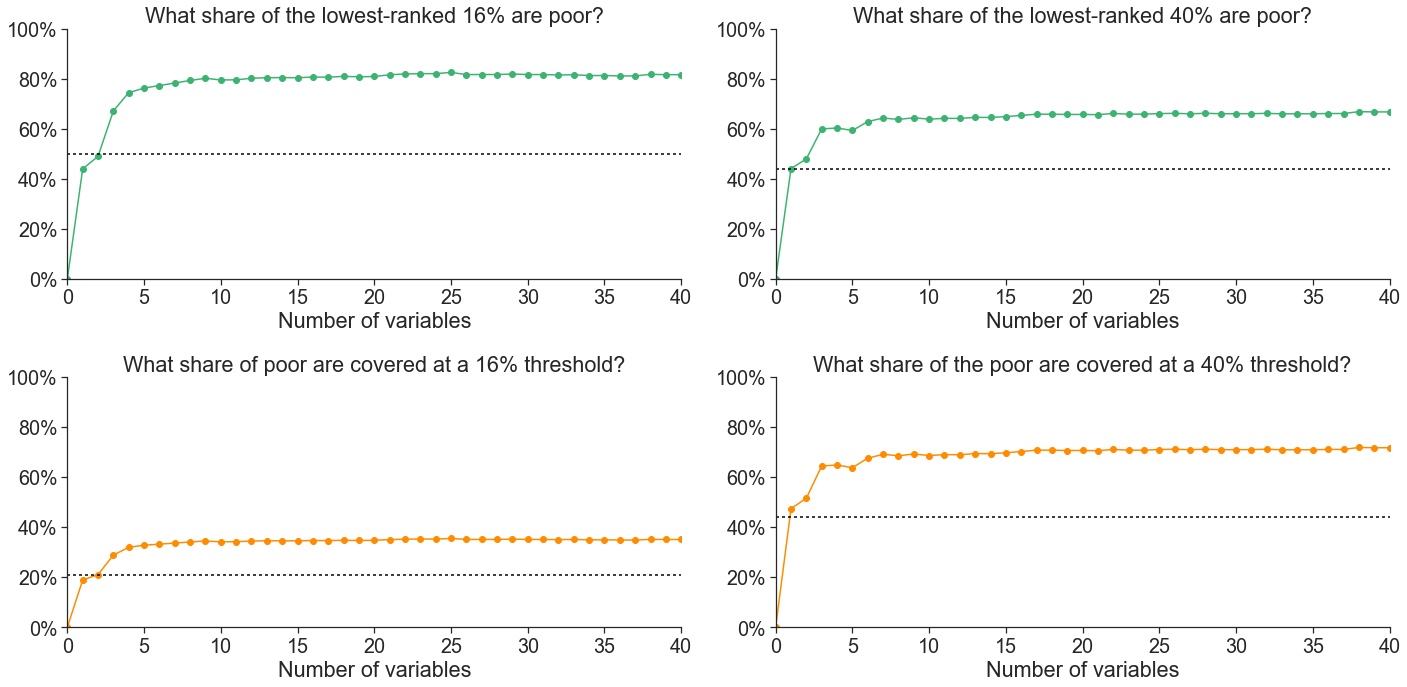

In [50]:
sns.set(font_scale=1.8, style='white')
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
nvars = [len(set([c.split('___')[0] for c in selected])) for selected in varlists]

ax[0, 0].plot([0] + nvars, [0] + [x*100 for x in prec_16s], marker='o', color='mediumseagreen', label='PMT')
ax[0, 1].plot([0] + nvars, [0] + [x*100 for x in prec_40s], marker='o', color='mediumseagreen', label='PMT')
ax[0, 0].axhline(50, label='Ubudehe', color='black', dashes=[2, 2])
ax[0, 1].axhline(44, label='Ubudehe', color='black', dashes=[2, 2])
simpleaxis(ax[0, 0])
simpleaxis(ax[0, 1])
ax[0, 0].set_xlabel('Number of variables')
ax[0, 1].set_xlabel('Number of variables')
ax[0, 0].set_title('What share of the lowest-ranked 16% are poor?')
ax[0, 1].set_title('What share of the lowest-ranked 40% are poor?')
ax[0, 0].set_ylim(0, 100)
ax[0, 1].set_ylim(0, 100)
ax[0, 0].set_xlim(0, 40)
ax[0, 1].set_xlim(0, 40)
ax[0, 0].yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax[0, 1].yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax[1, 0].plot([0] + nvars, [0] + [x*100 for x in recall_16s], marker='o', color='darkorange', label='PMT')
ax[1, 1].plot([0] + nvars, [0] + [x*100 for x in recall_40s], marker='o', color='darkorange', label='PMT')
ax[1, 0].axhline(21, label='Ubudehe', color='black', dashes=[2, 2])
ax[1, 1].axhline(44, label='Ubudehe', color='black', dashes=[2, 2])
simpleaxis(ax[1, 0])
simpleaxis(ax[1, 1])
ax[1, 0].set_xlabel('Number of variables')
ax[1, 1].set_xlabel('Number of variables')
ax[1, 0].set_title('What share of poor are covered at a 16% threshold?')
ax[1, 1].set_title('What share of the poor are covered at a 40% threshold?')
ax[1, 0].set_ylim(0, 100)
ax[1, 1].set_ylim(0, 100)
ax[1, 0].set_xlim(0, 40)
ax[1, 1].set_xlim(0, 40)
ax[1, 0].yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax[1, 1].yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.tight_layout()
#plt.savefig('Figures/stepwise_both.png', dpi=500)
plt.show()

### PMT coefficient graphs

In [10]:
def clean_var(v):
    if '___' in v:
        return v.split('___')[1].title()
    else:
        return v

In [11]:
def order_list(lst, labels):
    final_lst = []
    final_lst += [l for i, l in enumerate(lst) if labels[i] == 'house']
    final_lst += [l for i, l in enumerate(lst) if labels[i] == 'own']
    final_lst += [l for i, l in enumerate(lst) if labels[i] == 'demo']
    final_lst += [l for i, l in enumerate(lst) if labels[i] == 'hhh']
    color_lst = []
    color_lst += ['indianred' for l in labels if l == 'house']
    color_lst += ['darkorange' for l in labels if l == 'own']
    color_lst += ['mediumseagreen' for l in labels if l == 'demo']
    color_lst += ['slateblue' for l in labels if l == 'hhh']
    return list(reversed(final_lst)), list(reversed(color_lst))

IndexError: list index out of range

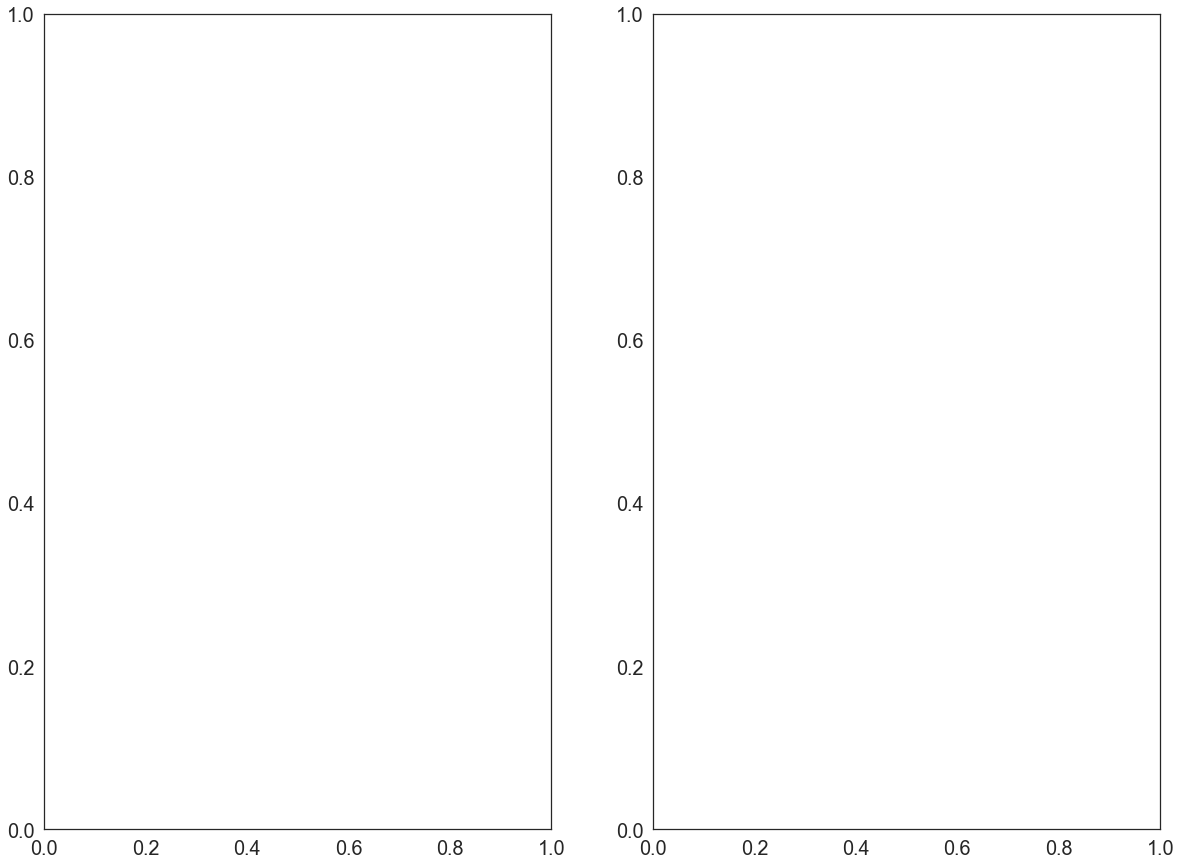

In [46]:
# 15 question PMT
to_save = []
numvars = 15
model = models[numvars - 1]
varlist = varlists[numvars - 1]
fig, ax = plt.subplots(1, 2, figsize=(20, 15))
labels = ['Cooking: Firewood', 'Cooking: Gas', 'Floor: Earth', 'Floor: Cement', 'Foor: Tiles',
         'Children under 18', 'Own phone', 'Own radio', 'Lighting: Electricity', 'HHH education: University', 
          'HHH education: Primary', 'HHH education: Secondary', 'Number of cattle', 'HHH married',
         'HHH widowed', 'HHH female', 'Own land', 'Number of goats', 'Household size', 'Own TV']
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
codes = ['house', 'house', 'house', 'house', 'house', 'demo', 'own', 'own', 'house', 'hhh', 'hhh', 'hhh',
         'own', 'hhh', 'hhh', 'hhh', 'own', 'own', 'demo', 'own']
labels, colors = order_list(labels, codes)
coefs, _ = order_list(coefs, codes)
to_save.append(pd.DataFrame([list(reversed(labels)), list(reversed(coefs))]).T)
#labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and not 'district' in v]

ax[0].barh(labels, coefs, color=colors, alpha=0.5, linewidth=2, edgecolor='black')
ax[0].axvline(0,  color='black')
simpleaxis(ax[0])

labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and 'district' in v]
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and 'district' in varlist[i]]
to_save.append(pd.DataFrame([['District: ' + l for l in labels], coefs]).T)
ax[1].barh(list(reversed(labels)), list(reversed(coefs)), color='steelblue', alpha=0.5, linewidth=2, 
           edgecolor='black')
ax[1].axvline(0, dashes=[2, 2], color='black')
simpleaxis(ax[1])
plt.tight_layout()
#plt.savefig('Figures/pmt15.png', dpi=500)
#plt.show()
to_save = pd.concat(to_save)
to_save.columns = ['Variable', 'Weight']
to_save['Weight'] = to_save['Weight'].apply(lambda x: '%.3f' % np.round(x, 3))
#to_save.to_csv('Coefs/15_question_pmt.csv', index=False)
print(model.intercept_)

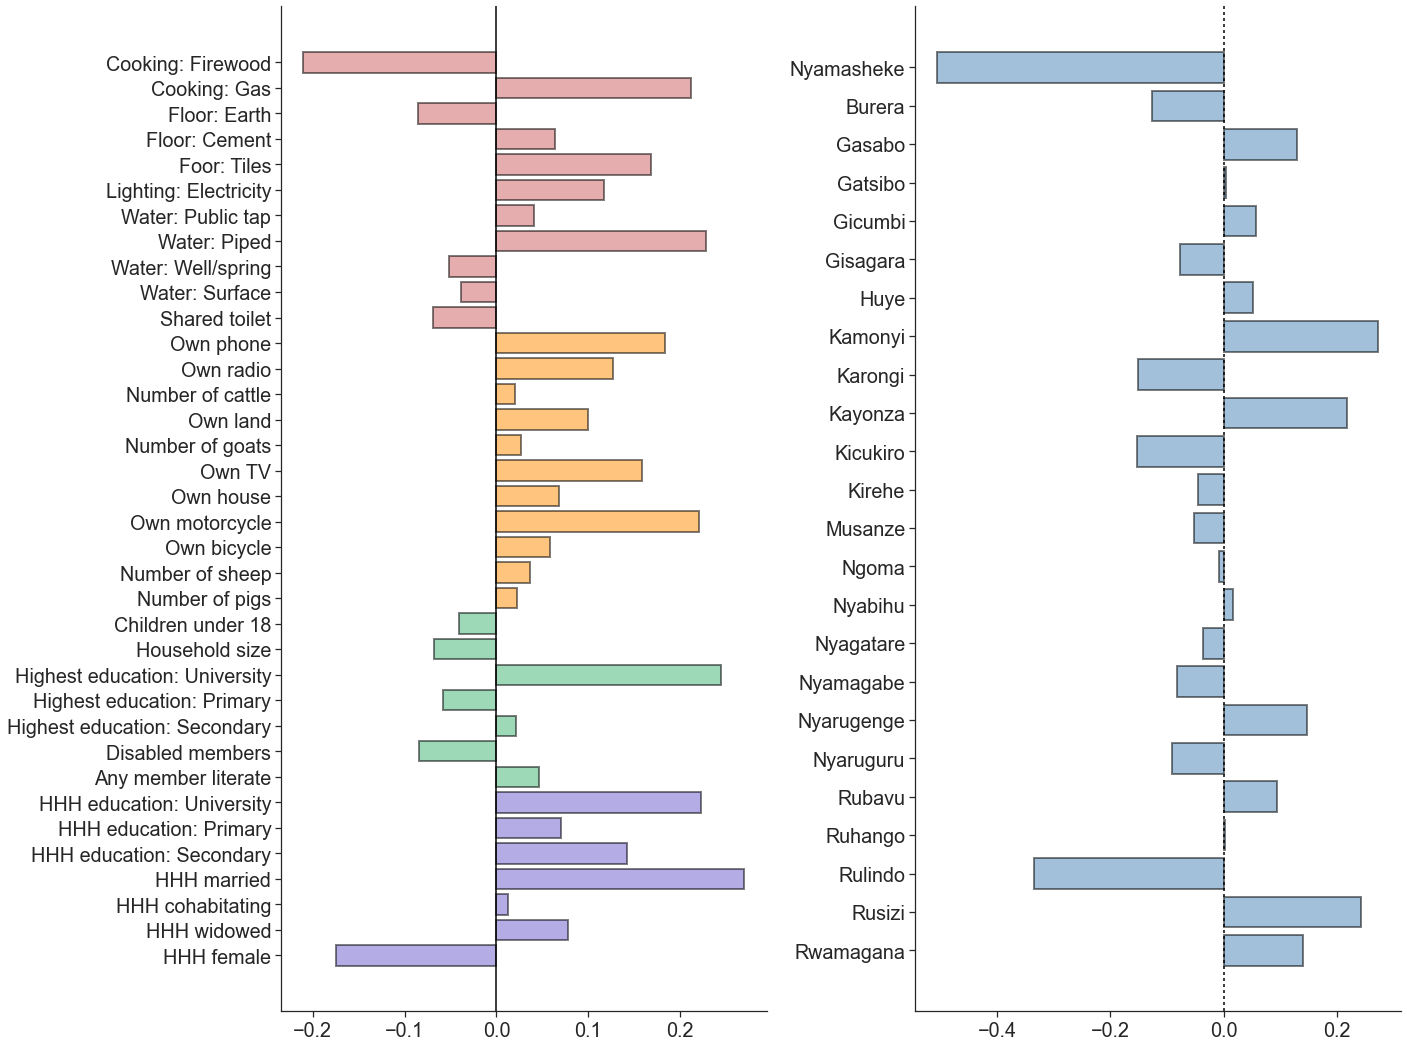

11.810726269171218


In [31]:
# 25 question PMT
to_save = []
numvars = 25
model = models[numvars - 1]
varlist = varlists[numvars - 1]
fig, ax = plt.subplots(1, 2, figsize=(20, 15))
labels = ['Cooking: Firewood', 'Cooking: Gas', 'Floor: Earth', 'Floor: Cement', 'Foor: Tiles',
         'Children under 18', 'Own phone', 'Own radio', 'Lighting: Electricity', 'HHH education: University', 
          'HHH education: Primary', 'HHH education: Secondary', 'Number of cattle', 'HHH married',
          'HHH cohabitating', 'HHH widowed', 'HHH female', 'Own land', 'Number of goats', 'Household size', 
          'Own TV', 'Water: Public tap', 'Water: Piped', 'Water: Well/spring', 'Water: Surface', 
          'Highest education: University', 'Highest education: Primary', 'Highest education: Secondary',
          'Own house', 'Disabled members', 'Own motorcycle', 'Shared toilet', 'Own bicycle', 'Number of sheep',
          'Number of pigs', 'Any member literate']
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
codes = ['house', 'house', 'house', 'house', 'house', 'demo', 'own', 'own', 'house', 'hhh', 'hhh', 'hhh',
         'own', 'hhh', 'hhh', 'hhh', 'hhh', 'own', 'own', 'demo', 'own', 'house', 'house', 'house', 'house',
         'demo', 'demo', 'demo', 'own', 'demo', 'own', 'house', 'own', 'own', 'own', 'demo']
labels, colors = order_list(labels, codes)
coefs, _ = order_list(coefs, codes)
to_save.append(pd.DataFrame([list(reversed(labels)), list(reversed(coefs))]).T)


#coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
#labels = [v for i, v in enumerate(varlist) if model.coef_[i] != 0 and not 'district' in v]
#print(labels)
ax[0].barh(labels, coefs, color=colors, alpha=0.5, linewidth=2, edgecolor='black')
ax[0].axvline(0,  color='black')
simpleaxis(ax[0])

labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and 'district' in v]
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and 'district' in varlist[i]]
to_save.append(pd.DataFrame([['District: ' + l for l in labels], coefs]).T)
ax[1].barh(list(reversed(labels)), list(reversed(coefs)), color='steelblue', alpha=0.5, linewidth=2, 
           edgecolor='black')
ax[1].axvline(0, dashes=[2, 2], color='black')
simpleaxis(ax[1])

plt.tight_layout()
plt.savefig('Figures/pmt25.png', dpi=500)
plt.show()

to_save = pd.concat(to_save)
to_save.columns = ['Variable', 'Weight']
to_save['Weight'] = to_save['Weight'].apply(lambda x: '%.3f' % np.round(x, 3))
to_save.to_csv('Coefs/25_question_pmt.csv', index=False)
print(model.intercept_)

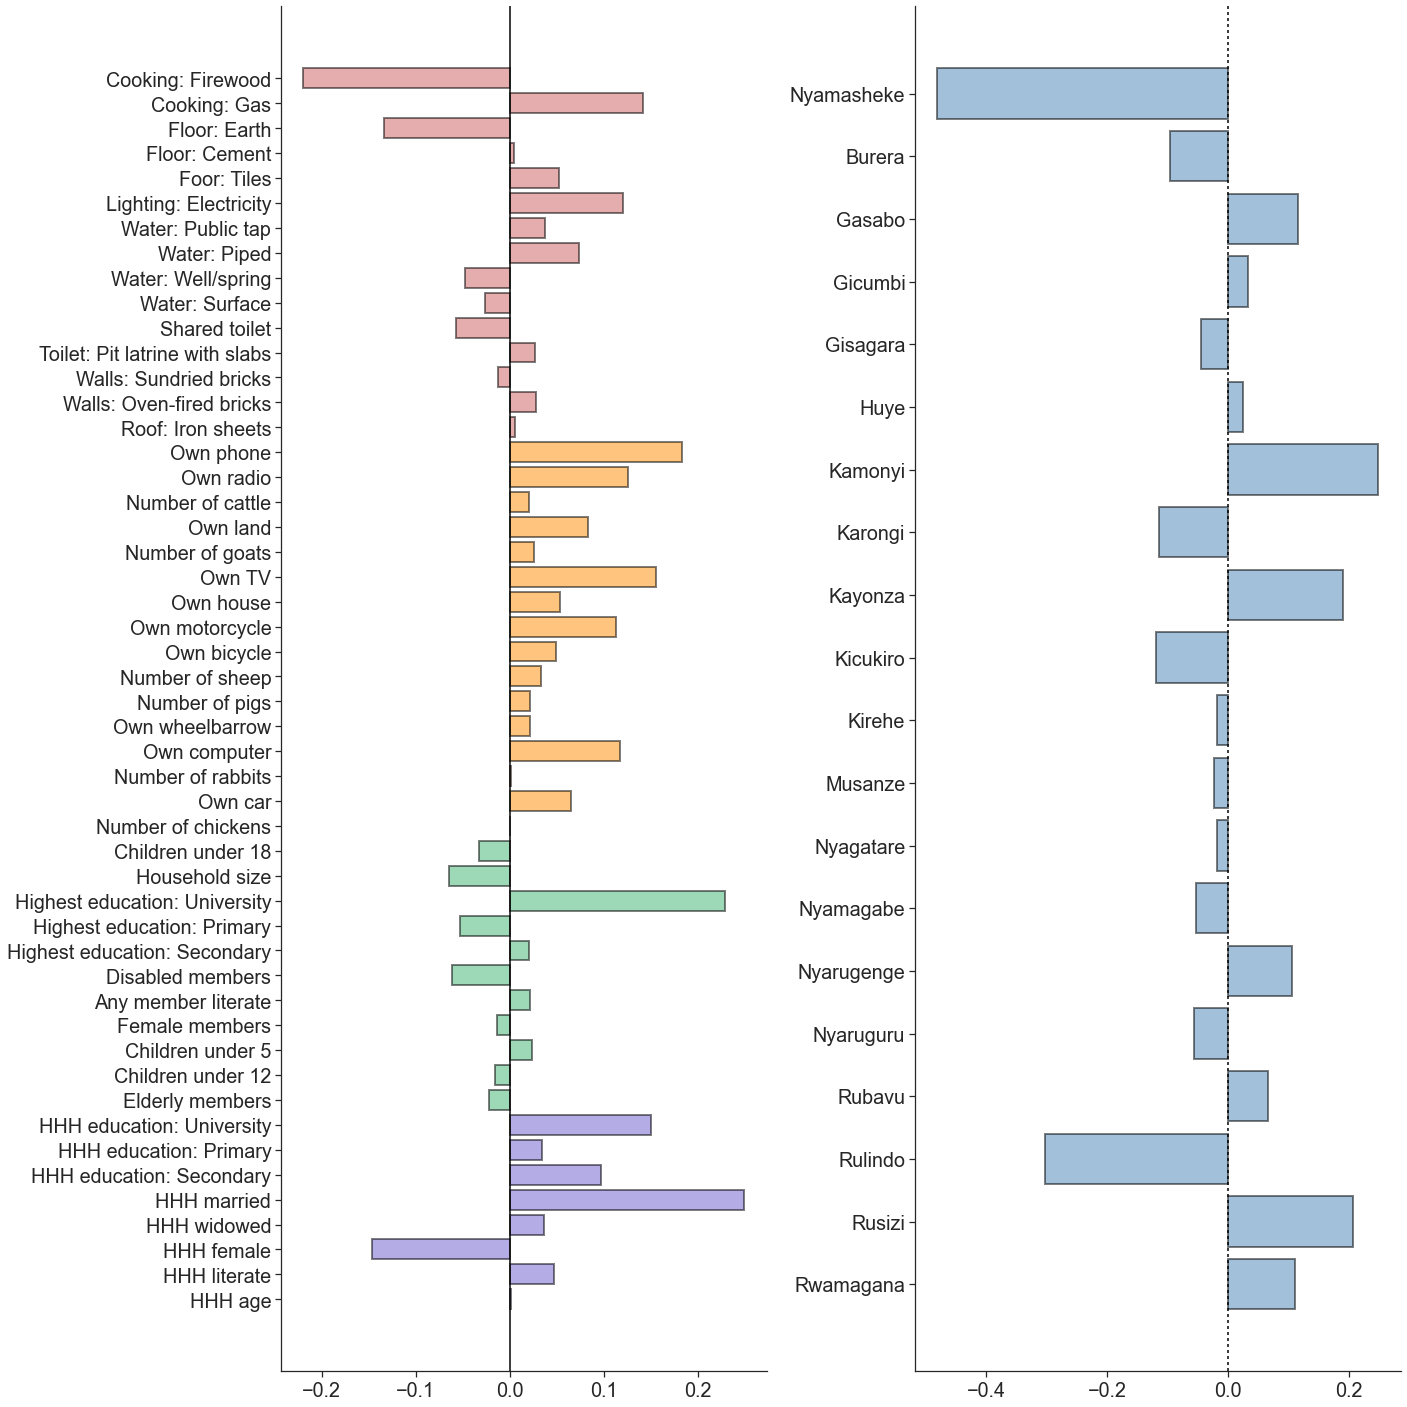

11.838070112344047


In [33]:
# 40 question PMT
to_save = []
numvars = 40
model = models[numvars - 1]
varlist = varlists[numvars - 1]
fig, ax = plt.subplots(1, 2, figsize=(20, 20))
labels = ['Cooking: Firewood', 'Cooking: Gas', 'Floor: Earth', 'Floor: Cement', 'Foor: Tiles',
         'Children under 18', 'Own phone', 'Own radio', 'Lighting: Electricity', 'HHH education: University', 
          'HHH education: Primary', 'HHH education: Secondary', 'Number of cattle', 'HHH married',
          'HHH widowed', 'HHH female', 'Own land', 'Number of goats', 'Household size', 
          'Own TV', 'Water: Public tap', 'Water: Piped', 'Water: Well/spring', 'Water: Surface', 
          'Highest education: University', 'Highest education: Primary', 'Highest education: Secondary',
          'Own house', 'Disabled members', 'Own motorcycle', 'Shared toilet', 'Own bicycle', 'Number of sheep',
          'Number of pigs', 'Any member literate', 'Toilet: Pit latrine with slabs', 'Walls: Sundried bricks',
          'Walls: Oven-fired bricks', 'Female members', 'Own wheelbarrow', 'Own computer', 'Number of rabbits',
          'Children under 5', 'HHH literate', 'Children under 12', 'Roof: Iron sheets', 'Own car', 'HHH age',
          'Elderly members', 'Number of chickens']
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
codes = ['house', 'house', 'house', 'house', 'house', 'demo', 'own', 'own', 'house', 'hhh', 'hhh', 'hhh',
         'own', 'hhh', 'hhh', 'hhh', 'own', 'own', 'demo', 'own', 'house', 'house', 'house', 'house',
         'demo', 'demo', 'demo', 'own', 'demo', 'own', 'house', 'own', 'own', 'own', 'demo', 'house',
         'house', 'house', 'demo', 'own', 'own', 'own', 'demo', 'hhh', 'demo', 'house', 'own', 'hhh', 'demo',
         'own']
labels, colors = order_list(labels, codes)
coefs, _ = order_list(coefs, codes)
to_save.append(pd.DataFrame([list(reversed(labels)), list(reversed(coefs))]).T)


#coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
#labels = [v for i, v in enumerate(varlist) if model.coef_[i] != 0 and not 'district' in v]
#print(labels)
ax[0].barh(labels, coefs, color=colors, alpha=0.5, linewidth=2, edgecolor='black')
ax[0].axvline(0,  color='black')
simpleaxis(ax[0])

labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and 'district' in v]
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and 'district' in varlist[i]]
to_save.append(pd.DataFrame([['District: ' + l for l in labels], coefs]).T)
ax[1].barh(list(reversed(labels)), list(reversed(coefs)), color='steelblue', alpha=0.5, linewidth=2, 
           edgecolor='black')
ax[1].axvline(0, dashes=[2, 2], color='black')
simpleaxis(ax[1])

plt.tight_layout()
plt.savefig('Figures/pmt40.png', dpi=500)
plt.show()

to_save = pd.concat(to_save)
to_save.columns = ['Variable', 'Weight']
to_save['Weight'] = to_save['Weight'].apply(lambda x: '%.3f' % np.round(x, 3))
to_save.to_csv('Coefs/40_question_pmt.csv', index=False)
print(model.intercept_)

### Simulation of beneficiary lists

In [197]:
numvars = 15
model = models[numvars - 1]
varlist = varlists[numvars - 1]
test['prediction'] = model.predict(test[varlist])
test['targeted'] = test['prediction'] < np.percentile(test['prediction'], 40)
sr['prediction'] = model.predict(sr[varlist])
sr['targeted'] = sr['prediction'] < np.percentile(sr['prediction'], 40)

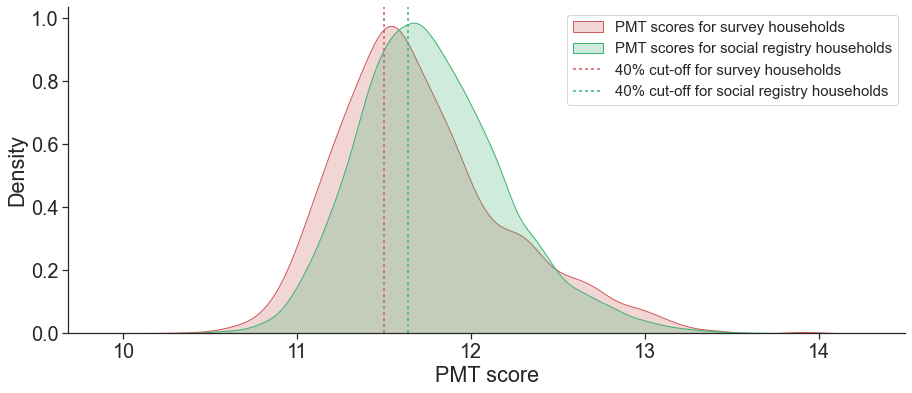

In [208]:
fig, ax = plt.subplots(1, figsize=(15, 6))
sns.kdeplot(test, x='prediction', ax=ax, shade=True, weights='weight_new', color='indianred',
           label='PMT scores for survey households')
sns.kdeplot(sr, x='prediction', ax=ax, shade=True, color='mediumseagreen',
           label='PMT scores for social registry households')
ax.axvline(test[test['targeted'] == 1]['prediction'].max(), color='indianred', dashes=[2, 2],
          label='40% cut-off for survey households')
ax.axvline(sr[sr['targeted'] == 1]['prediction'].max(), color='mediumseagreen', dashes=[2, 2],
          label='40% cut-off for social registry households')
ax.legend(loc='best', fontsize='x-small')
ax.set_xlabel('PMT score')
simpleaxis(ax)
plt.savefig('Figures/hist.png')
plt.show()

In [150]:
previous_vup = test[(test['categorical_vup'] == 1) & (test['ubudehe_cat'] == 1)]

new_vup = test[(test['categorical_vup'] == 1) & (test['targeted'] == 1)]
both_vup = test[(test['categorical_vup'] == 1) & (test['targeted'] == 1) & 
                   (test['ubudehe_cat'] == 1)]
print('Share previous VUP beneficairies: %.3f' % (previous_vup['weight_new'].sum()/test['weight_new'].sum()))
print('Share new VUP beneficairies: %.3f' % (new_vup['weight_new'].sum()/test['weight_new'].sum()))
print('Share of previous beneficiaries continuing: %.3f' % 
      (both_vup['weight_new'].sum()/previous_vup['weight_new'].sum()))

Share previous VUP beneficairies: 0.029
Share new VUP beneficairies: 0.028
Share of previous beneficiaries continuing: 0.568


In [151]:
previous_vup = sr[(sr['former_beneficiary'] == 1)]
print('Share previous VUP beneficaires who meet categorical criteria: %.2f' % 
      (len(previous_vup[previous_vup['categorical_vup'] == 1])/len(previous_vup)))

new_vup = sr[(sr['categorical_vup'] == 1) & (sr['targeted'] == 1)]
both_vup = sr[(sr['categorical_vup'] == 1) & (sr['targeted'] == 1) & (sr['former_beneficiary'] == 1)]
print('Share previous VUP beneficairies: %.3f' % (len(previous_vup)/len(sr)))
print('Share new VUP beneficairies: %.3f' % (len(new_vup)/len(sr)))
print('Share of previous beneficiaries continuing: %.3f' % (len(both_vup)/len(previous_vup)))
print('Share of previous beneficiaries who meet categorical criteria continuing: %.3f' % 
      (len(both_vup)/len(previous_vup[previous_vup['categorical_vup'] == 1])))

Share previous VUP beneficaires who meet categorical criteria: 0.54
Share previous VUP beneficairies: 0.033
Share new VUP beneficairies: 0.044
Share of previous beneficiaries continuing: 0.390
Share of previous beneficiaries who meet categorical criteria continuing: 0.721


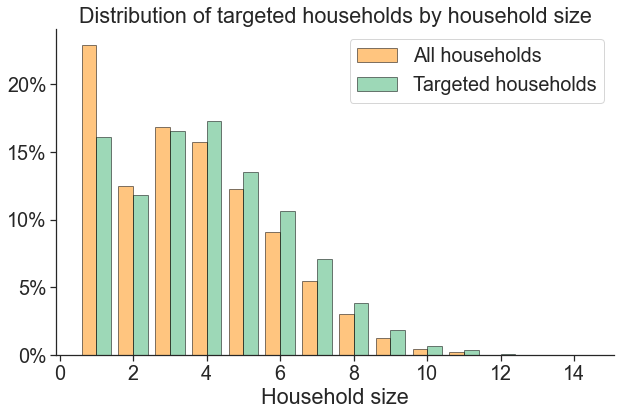

In [179]:
fig, ax = plt.subplots(1, figsize=(10, 6))
g1 = sr.groupby('hhsize', as_index=False).agg('count')
g1['code'] = 100*g1['code']/g1['code'].sum()
g2 = sr[sr['targeted'] == 1].groupby('hhsize', as_index=False).agg('count')
g2['code'] = 100*g2['code']/g2['code'].sum()
ax.bar(g1['hhsize'] - 0.2, g1['code'], width=0.4, color='darkorange', alpha=0.5, edgecolor='black',
      linewidth=1, label='All households')
ax.bar(g2['hhsize'] + 0.2, g2['code'], width=0.4, color='mediumseagreen', alpha=0.5, edgecolor='black',
      linewidth=1, label='Targeted households')
simpleaxis(ax)
ax.legend(loc='best')
ax.set_xlabel('Household size')
ax.set_title('Distribution of targeted households by household size')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.savefig('Figures/hhsize.png', dpi=500)
plt.show()

### LASSO selection of predictors

In [171]:
train, test = train_test_split(eicv, test_size=0.25, random_state=9, shuffle=True, 
                               stratify=eicv['ubudehe_cat'])
xvars = [c for c in eicv.columns if c not in outcomes]
x_train, x_test = train[xvars], test[xvars]
outcome = 'log_consumption'
y_train, y_test = train[outcome], test[outcome]
weights_train, weights_test = train['weight_new'], test['weight_new']

r2s, spearmans, prec_16s, prec_40s = [], [], [], []
models, all_selecteds, unique_selecteds, nvars = [], [], [], []
for i, alpha in enumerate([0] + list(np.logspace(-3, 1, 500))):
    
    print(str(i) + '/500', end='\r')
    model = Lasso(alpha=alpha)
    model.fit(x_train, y_train)
    yhat_test = model.predict(x_test)
    selected = [c for i, c in enumerate(x_train.columns) if model.coef_[i] != 0]
    unique_selected = ordered_set([c.split('___')[0] for c in selected])
    
    if len(nvars) == 0 or nvars[-1] != len(unique_selected):
        models.append(model)
        all_selecteds.append(selected)
        unique_selecteds.append(unique_selected)
        nvars.append(len(unique_selected))
        
        r2 = r2_score(y_test, yhat_test, sample_weight=weights_test)
        spearman = weighted_spearman(y_test, yhat_test, weights_test)
        r2s.append(r2)
        spearmans.append(spearman)
        
        # Accuracy - 16% cut-off
        evalset = test.copy()
        evalset['prediction_lr'] = model.predict(x_test)
        weight_targeted = 0.16*evalset['weight_new'].sum()
        evalset = evalset.sort_values('prediction_lr', ascending=True)
        evalset['cum_weight'] = evalset['weight_new'].cumsum()
        evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
        targeted = evalset[evalset['targeted'] == 1]
        pmt_accuracy_16 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
        prec_16s.append(pmt_accuracy_16)

        # Accuracy - 40% cut-off
        evalset = test.copy()
        evalset['prediction_lr'] = model.predict(x_test)
        weight_targeted = 0.40*evalset['weight_new'].sum()
        evalset = evalset.sort_values('prediction_lr', ascending=True)
        evalset['cum_weight'] = evalset['weight_new'].cumsum()
        evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
        targeted = evalset[evalset['targeted'] == 1]
        pmt_accuracy_40 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
        prec_40s.append(pmt_accuracy_40)
        
sns.set(font_scale=1.8, style='white')
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

ax[0].plot(nvars,[x*100 for x in prec_16s], marker='o', color='mediumseagreen', label='PMT')
ax[1].plot(nvars, [x*100 for x in prec_40s], marker='o', color='mediumseagreen', label='PMT')
ax[0].axhline(50, label='Ubudehe', color='black', dashes=[2, 2])
ax[1].axhline(44, label='Ubudehe', color='black', dashes=[2, 2])
simpleaxis(ax[0])
simpleaxis(ax[1])
ax[0].set_xlabel('Number of variables')
ax[1].set_xlabel('Number of variables')
ax[0].set_title('What share of the lowest-ranked 16% are poor?')
ax[1].set_title('What share of the lowest-ranked 40% are poor?')
ax[0].set_ylim(0, 100)
ax[1].set_ylim(0, 100)
ax[0].set_xlim(0, 43)
ax[1].set_xlim(0, 43)
ax[-1].legend(loc='best')
ax[0].yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.tight_layout()
#plt.savefig('stepwise.png', dpi=500)
plt.show()

### Adding sheep + pigs

In [10]:
selected = varlists[14] + ['number_Sheep', 'number_Pigs']
selected = [c for c in selected if 'radio' not in c and 'television' not in c]

In [11]:
n_folds = 3
random_seed = 0

xvars = [c for c in eicv.columns if c not in outcomes]
x_train, x_test = train[xvars], test[xvars]
outcome = 'log_consumption'
y_train, y_test = train[outcome], test[outcome]
weights_train, weights_test = train['weight_new'], test['weight_new']
kfold = KFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
train_ids, val_ids = train_test_split(range(len(y_train)), random_state=random_seed, test_size=0.25)
remaining = list(x_train.columns)

model = LassoCV()
model.fit(x_train[selected], y_train, sample_weight=weights_train)
yhat_test = model.predict(x_test[selected])
r2 = r2_score(y_test, yhat_test, sample_weight=weights_test)
spearman = weighted_spearman(y_test, yhat_test, weights_test)

# Accuracy - 16% cut-off
evalset = test.copy()
evalset['prediction_lr'] = model.predict(x_test[selected])
weight_targeted = 0.16*evalset['weight_new'].sum()
evalset = evalset.sort_values('prediction_lr', ascending=True)
evalset['cum_weight'] = evalset['weight_new'].cumsum()
evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
targeted = evalset[evalset['targeted'] == 1]
pmt_accuracy_16 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
poor = evalset[evalset['below_pl'] == 1]
pmt_recall_16 = poor[poor['targeted'] == 1]['weight_new'].sum()/poor['weight_new'].sum()

# Accuracy - 40% cut-off
evalset = test.copy()
evalset['prediction_lr'] = model.predict(x_test[selected])
weight_targeted = 0.40*evalset['weight_new'].sum()
evalset = evalset.sort_values('prediction_lr', ascending=True)
evalset['cum_weight'] = evalset['weight_new'].cumsum()
evalset['targeted'] = evalset['cum_weight'] <= weight_targeted
targeted = evalset[evalset['targeted'] == 1]
pmt_accuracy_40 = targeted[targeted['below_pl'] == 1]['weight_new'].sum()/targeted['weight_new'].sum()
poor = evalset[evalset['below_pl'] == 1]
pmt_recall_40 = poor[poor['targeted'] == 1]['weight_new'].sum()/poor['weight_new'].sum()

print(np.round(spearman, 2), np.round(pmt_accuracy_16, 2),  np.round(pmt_accuracy_40, 2))

0.56 0.79 0.64


In [13]:
model.intercept_

11.813212136688872

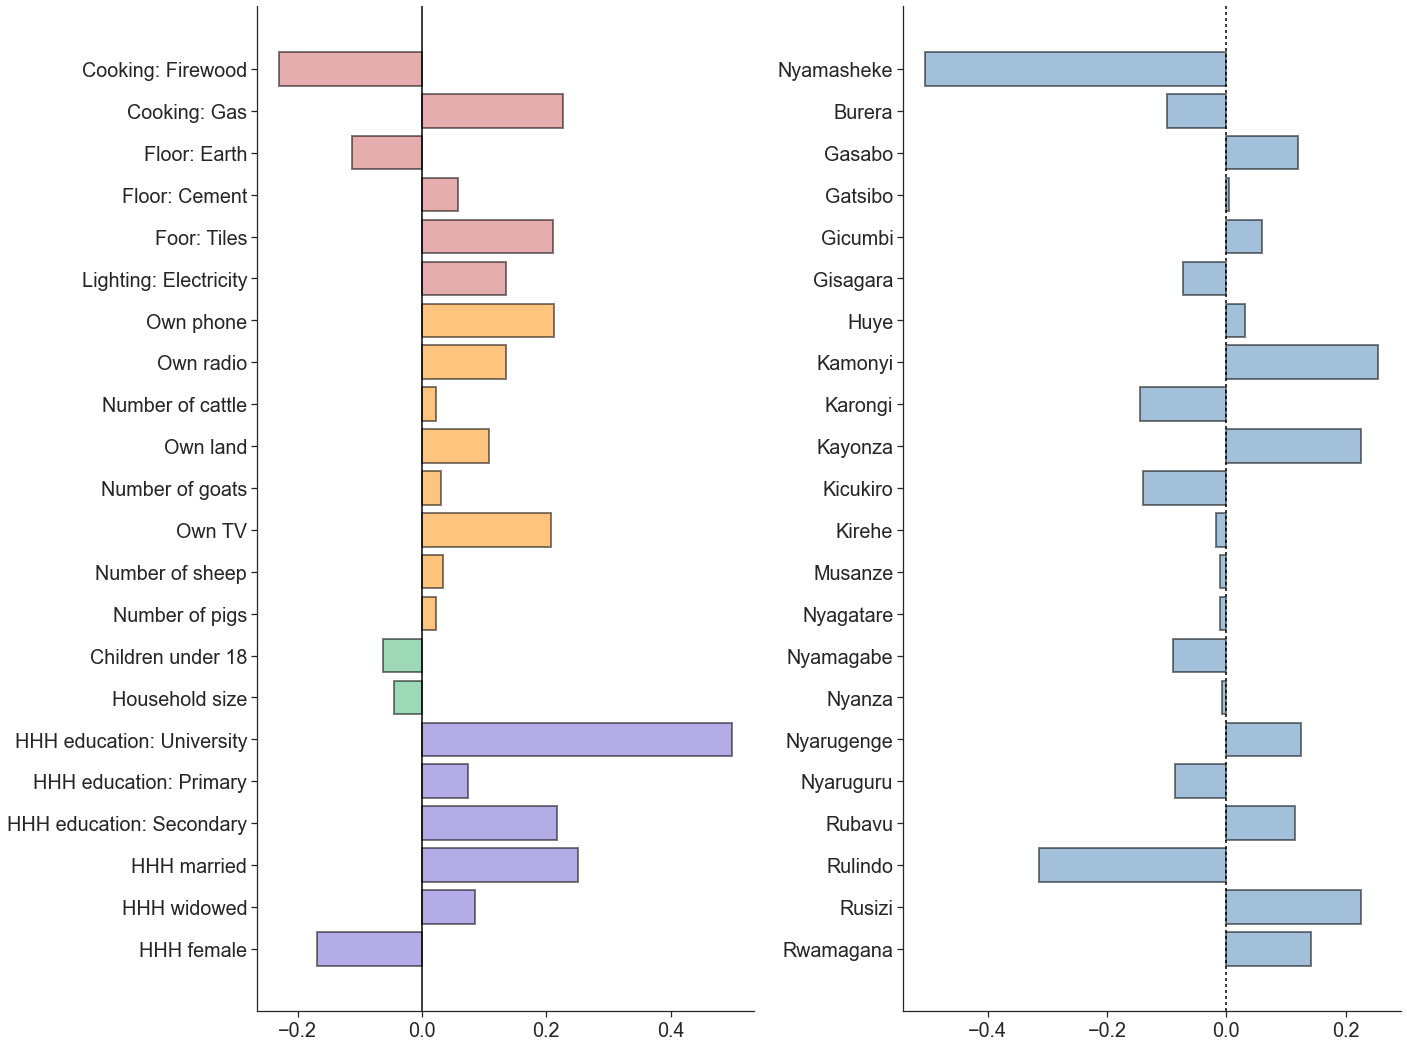

11.787168989854742


In [56]:
to_save = []
numvars = 15
#model = models[numvars - 1]
varlist = selected
fig, ax = plt.subplots(1, 2, figsize=(20, 15))
labels = ['Cooking: Firewood', 'Cooking: Gas', 'Floor: Earth', 'Floor: Cement', 'Foor: Tiles',
         'Children under 18', 'Own phone', 'Own radio', 'Lighting: Electricity', 'HHH education: University', 
          'HHH education: Primary', 'HHH education: Secondary', 'Number of cattle', 'HHH married',
         'HHH widowed', 'HHH female', 'Own land', 'Number of goats', 'Household size', 'Own TV', 
         'Number of sheep', 'Number of pigs']
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and not 'district' in varlist[i]]
codes = ['house', 'house', 'house', 'house', 'house', 'demo', 'own', 'own', 'house', 'hhh', 'hhh', 'hhh',
         'own', 'hhh', 'hhh', 'hhh', 'own', 'own', 'demo', 'own', 'own', 'own']
labels, colors = order_list(labels, codes)
coefs, _ = order_list(coefs, codes)
to_save.append(pd.DataFrame([list(reversed(labels)), list(reversed(coefs))]).T)
#labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and not 'district' in v]

ax[0].barh(labels, coefs, color=colors, alpha=0.5, linewidth=2, edgecolor='black')
ax[0].axvline(0,  color='black')
simpleaxis(ax[0])

labels = [clean_var(v) for i, v in enumerate(varlist) if model.coef_[i] != 0 and 'district' in v]
coefs = [c for i, c in enumerate(model.coef_) if c != 0 and 'district' in varlist[i]]
to_save.append(pd.DataFrame([['District: ' + l for l in labels], coefs]).T)
ax[1].barh(list(reversed(labels)), list(reversed(coefs)), color='steelblue', alpha=0.5, linewidth=2, 
           edgecolor='black')
ax[1].axvline(0, dashes=[2, 2], color='black')
simpleaxis(ax[1])
plt.tight_layout()
plt.savefig('Figures/pmt15_with_pigs_sheep.png', dpi=500)
plt.show()
to_save = pd.concat(to_save)
to_save.columns = ['Variable', 'Weight']
to_save['Weight'] = to_save['Weight'].apply(lambda x: '%.3f' % np.round(x, 3))
to_save.to_csv('Coefs/15_question_pmt_with_sheep_pigs.csv', index=False)
print(model.intercept_)